In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df = pd.read_csv('crop_yield.csv')

print(df.head())
print(df.shape)


           Crop  Crop_Year       Season  State     Area  Production  \
0      Arecanut       1997  Whole Year   Assam  73814.0       56708   
1     Arhar/Tur       1997  Kharif       Assam   6637.0        4685   
2   Castor seed       1997  Kharif       Assam    796.0          22   
3      Coconut        1997  Whole Year   Assam  19656.0   126905000   
4  Cotton(lint)       1997  Kharif       Assam   1739.0         794   

   Annual_Rainfall  Fertilizer  Pesticide        Yield  
0           2051.4  7024878.38   22882.34     0.796087  
1           2051.4   631643.29    2057.47     0.710435  
2           2051.4    75755.32     246.76     0.238333  
3           2051.4  1870661.52    6093.36  5238.051739  
4           2051.4   165500.63     539.09     0.420909  
(19689, 10)


In [10]:
print(df.info())
print(df.describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Crop             19689 non-null  object 
 1   Crop_Year        19689 non-null  int64  
 2   Season           19689 non-null  object 
 3   State            19689 non-null  object 
 4   Area             19689 non-null  float64
 5   Production       19689 non-null  int64  
 6   Annual_Rainfall  19689 non-null  float64
 7   Fertilizer       19689 non-null  float64
 8   Pesticide        19689 non-null  float64
 9   Yield            19689 non-null  float64
dtypes: float64(5), int64(2), object(3)
memory usage: 1.5+ MB
None
          Crop_Year          Area    Production  Annual_Rainfall  \
count  19689.000000  1.968900e+04  1.968900e+04     19689.000000   
mean    2009.127584  1.799266e+05  1.643594e+07      1437.755177   
std        6.498099  7.328287e+05  2.630568e+08       816.909589   


In [11]:
# Missing values
print(df.isnull().sum())

# Drop missing values
df = df.dropna()

# Remove duplicates
df = df.drop_duplicates()


Crop               0
Crop_Year          0
Season             0
State              0
Area               0
Production         0
Annual_Rainfall    0
Fertilizer         0
Pesticide          0
Yield              0
dtype: int64


In [12]:
num_df = df.select_dtypes(include=['number'])
cat_df = df.select_dtypes(include=['object'])

In [19]:
df['Crop'].value_counts()
df['Season'].value_counts()
df['State'].value_counts()


State
Karnataka            1432
Andhra Pradesh       1266
West Bengal          1094
Chhattisgarh          915
Bihar                 896
Madhya Pradesh        845
Uttar Pradesh         825
Tamil Nadu            822
Gujarat               817
Maharashtra           770
Uttarakhand           764
Odisha                760
Assam                 731
Nagaland              689
Puducherry            670
Meghalaya             649
Jammu and Kashmir     631
Haryana               631
Himachal Pradesh      616
Kerala                534
Manipur               444
Tripura               441
Mizoram               416
Punjab                397
Telangana             397
Arunachal Pradesh     292
Jharkhand             270
Goa                   246
Sikkim                226
Delhi                 203
Name: count, dtype: int64

In [20]:
print(num_df.quantile([0.25, 0.5, 0.75]))


      Crop_Year     Area  Production  Annual_Rainfall   Fertilizer  Pesticide  \
0.25     2004.0   1390.0      1393.0            940.7    188014.62      356.7   
0.50     2010.0   9317.0     13804.0           1247.6   1234957.44     2421.9   
0.75     2015.0  75112.0    122718.0           1643.7  10003847.20    20041.7   

         Yield  
0.25  0.600000  
0.50  1.030000  
0.75  2.388889  


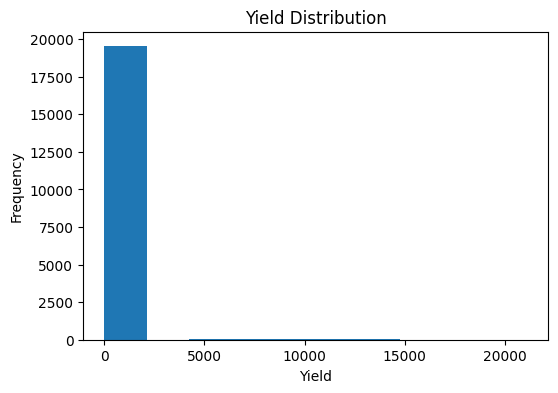

In [21]:
# Histogram
plt.figure(figsize=(6,4))
plt.hist(df['Yield'])
plt.title('Yield Distribution')
plt.xlabel('Yield')
plt.ylabel('Frequency')
plt.show()


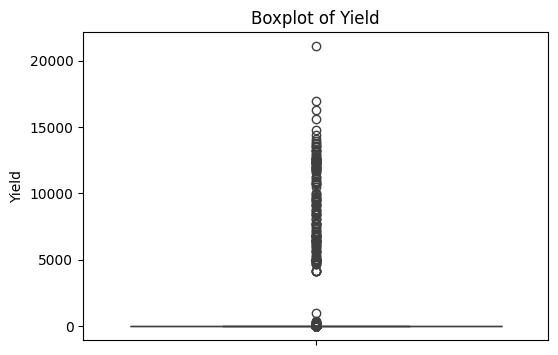

In [22]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df['Yield'])
plt.title('Boxplot of Yield')
plt.show()

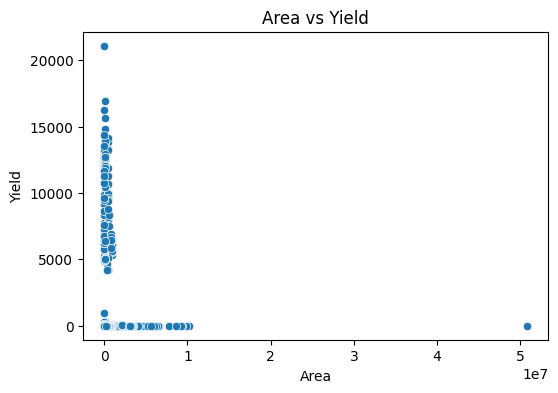

In [25]:
# Scatter
plt.figure(figsize=(6,4))
sns.scatterplot(x='Area', y='Yield', data=df)
plt.title('Area vs Yield')
plt.show()

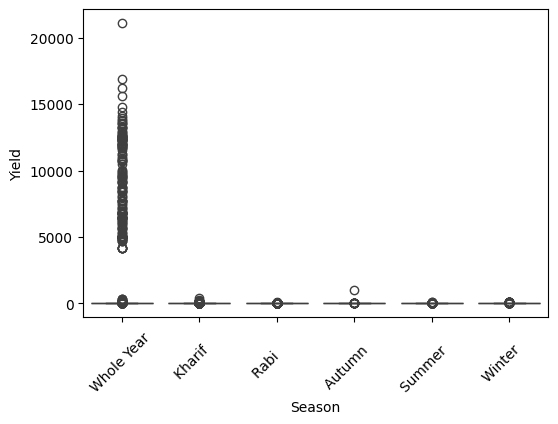

In [26]:
# Boxplot
plt.figure(figsize=(6,4))
sns.boxplot(x='Season', y='Yield', data=df)
plt.xticks(rotation=45)
plt.show()


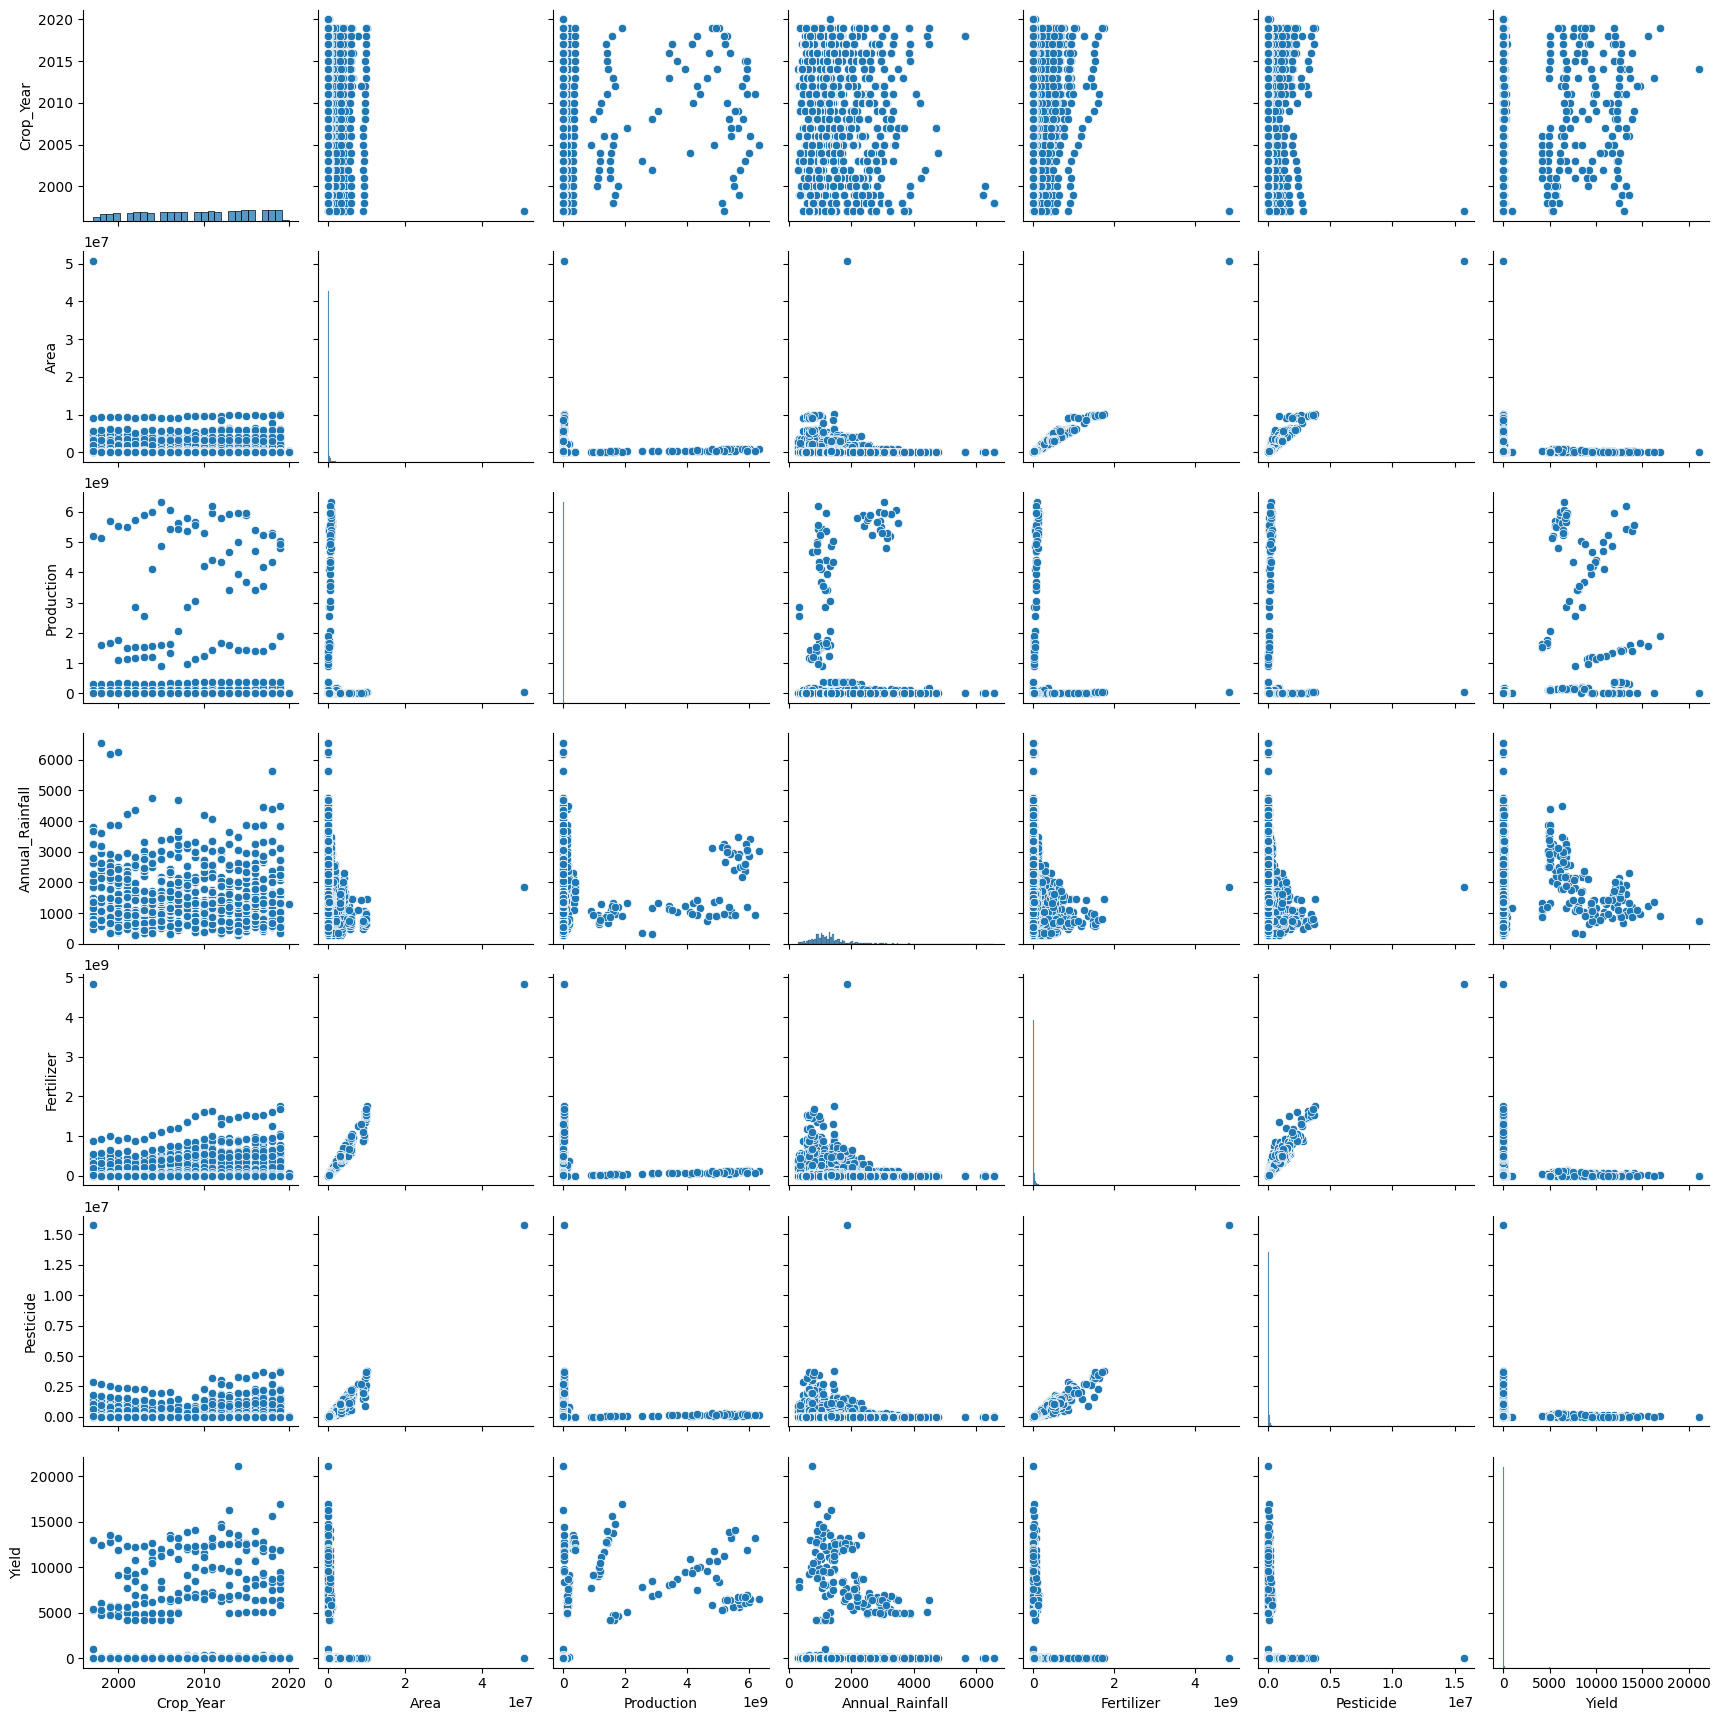

In [27]:
sns.pairplot(num_df)
plt.show()

In [29]:
num_cols = df.select_dtypes(include='number')

X = num_cols.drop('Yield', axis=1)
y = df['Yield']

In [30]:
X = df[['Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Area']]
y = df['Yield']

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [32]:
#DECISION TREE REGRESSION
# ==============================
from sklearn.tree import DecisionTreeRegressor

reg = DecisionTreeRegressor()
reg.fit(X_train, y_train)

y_pred = reg.predict(X_test)

# Evaluation
from sklearn.metrics import mean_squared_error

print("MSE:", mean_squared_error(y_test, y_pred))

MSE: 1270722.1338977988


In [38]:
#  DECISION TREE CLASSIFICATION

In [39]:
# Convert target
df['Yield_Class'] = pd.cut(df['Yield'], bins=3, labels=['Low', 'Medium', 'High'])

# Use only numeric features
X_cls = df[['Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Area']]
y_cls = df['Yield_Class']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_cls, y_cls, test_size=0.2)

from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier()

clf.fit(X_train, y_train)

y_pred_cls = clf.predict(X_test)

from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred_cls)*100)

Accuracy: 99.18740477399696


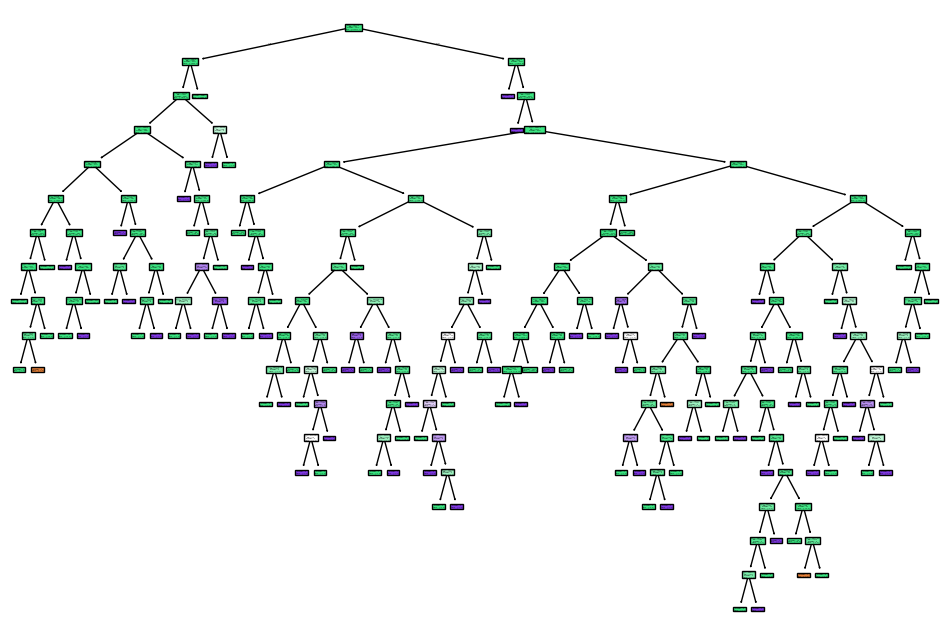

In [40]:
from sklearn.tree import plot_tree

plt.figure(figsize=(12,8))
plot_tree(clf, filled=True)
plt.show()